In [2]:
import tensorflow as tf
import numpy as np
import json
import os
from tensorflow.keras import Sequential, layers
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, GlobalAveragePooling2D, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pathlib import Path

# Congelar semilla para reproducibilidad
import random
seed_value = 67
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


In [3]:
# ============================================================
# 1) Parameters
# ============================================================

IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
EPOCHS = 50

BASE_DIR = Path.cwd()

TRAIN_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "train"
VALIDATION_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "validation"
TEST_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "test"


In [4]:
# ============================================================
# 2) Data Generators
# ============================================================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    VALIDATION_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)


Found 20938 images belonging to 10 classes.
Found 2614 images belonging to 10 classes.
Found 2627 images belonging to 10 classes.


In [5]:
# ============================================================
# 3) Class Mapping & Weights
# ============================================================

class_indices = train_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}


# Guardar mapeo de clases
class_mapping_path = os.path.join(os.getcwd(), "mapeo_clases_CM.json")
with open(class_mapping_path, "w", encoding="utf-8") as f:
    json.dump({"class_indices": class_indices, "index_to_class": index_to_class}, f, indent=2)
print("Mapeo de clases guardado en:", class_mapping_path)

# Calcular class weights para compensar desbalance
num_classes = train_generator.num_classes

train_counts = {}
for class_name in class_indices:
    class_dir = os.path.join(TRAIN_DATA_DIR, class_name)
    train_counts[class_name] = len(os.listdir(class_dir))

total_train = sum(train_counts.values())

class_weight = {}
for class_name, class_index in class_indices.items():
    class_count = train_counts[class_name]
    class_weight[class_index] = total_train / (num_classes * class_count)

print("\nClass weights:")
for class_index, weight in class_weight.items():
    print(f"  {class_index} ({index_to_class[class_index]}): {weight:.4f}")


Mapeo de clases guardado en: c:\IA-FAC\mapeo_clases_CM.json

Class weights:
  0 (araña): 0.5430
  1 (ardilla): 1.4062
  2 (caballo): 0.9980
  3 (elefante): 1.8112
  4 (gallina): 0.8450
  5 (gato): 1.5696
  6 (mariposa): 1.2397
  7 (oveja): 1.4380
  8 (perro): 0.5383
  9 (vaca): 1.4034


In [6]:
# ============================================================
# 4) Build and Compile Custom Model
# ============================================================

# Nota: NO usamos Rescaling dentro del modelo porque ya aplicamos
# rescale=1./255 en el ImageDataGenerator.

model = Sequential([
    Conv2D(32, 3, padding="same", activation="relu", input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, 3, padding="same", activation="relu"),
    BatchNormalization(),

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(train_generator.num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 64)     256       
 hNormalization)                                                 
                                                        

In [7]:
# ============================================================
# 5) Callbacks
# ============================================================

checkpoint_path = os.path.join(os.getcwd(), "mejor_modelo_CM.keras")

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, checkpoint, reduce_lr]


In [8]:
# ============================================================
# 6) Training
# ============================================================

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)


Epoch 1/50
655/655 [==============================] - ETA: 0s - loss: 2.1798 - accuracy: 0.2620
Epoch 1: val_accuracy improved from -inf to 0.34315, saving model to c:\IA-FAC\mejor_modelo_CM.keras
655/655 [==============================] - 208s 313ms/step - loss: 2.1798 - accuracy: 0.2620 - val_loss: 1.9288 - val_accuracy: 0.3432 - lr: 1.0000e-04
Epoch 2/50
655/655 [==============================] - ETA: 0s - loss: 1.8713 - accuracy: 0.3497
Epoch 2: val_accuracy improved from 0.34315 to 0.37337, saving model to c:\IA-FAC\mejor_modelo_CM.keras
655/655 [==============================] - 186s 284ms/step - loss: 1.8713 - accuracy: 0.3497 - val_loss: 1.9759 - val_accuracy: 0.3734 - lr: 1.0000e-04
Epoch 3/50
655/655 [==============================] - ETA: 0s - loss: 1.6987 - accuracy: 0.3970
Epoch 3: val_accuracy improved from 0.37337 to 0.43076, saving model to c:\IA-FAC\mejor_modelo_CM.keras
655/655 [==============================] - 180s 275ms/step - loss: 1.6987 - accuracy: 0.3970 - val_

In [9]:
# ============================================================
# 7) Save Final Model
# ============================================================

final_model_path = os.path.join(os.getcwd(), "modelo_final_CM.keras")

model.save(final_model_path)

print("Modelo final guardado en:", final_model_path)
print("Mejor modelo guardado en:", checkpoint_path)
print("Mapeo de clases guardado en:", class_mapping_path)


Modelo final guardado en: c:\IA-FAC\modelo_final_CM.keras
Mejor modelo guardado en: c:\IA-FAC\mejor_modelo_CM.keras
Mapeo de clases guardado en: c:\IA-FAC\mapeo_clases_CM.json


In [10]:
# ============================================================
# 8) Evaluation on Test Set
# ============================================================

best_model = load_model(checkpoint_path)

test_loss, test_acc = best_model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


83/83 [==============================] - 6s 64ms/step - loss: 0.8774 - accuracy: 0.7168
Test Loss: 0.8774
Test Accuracy: 0.7168


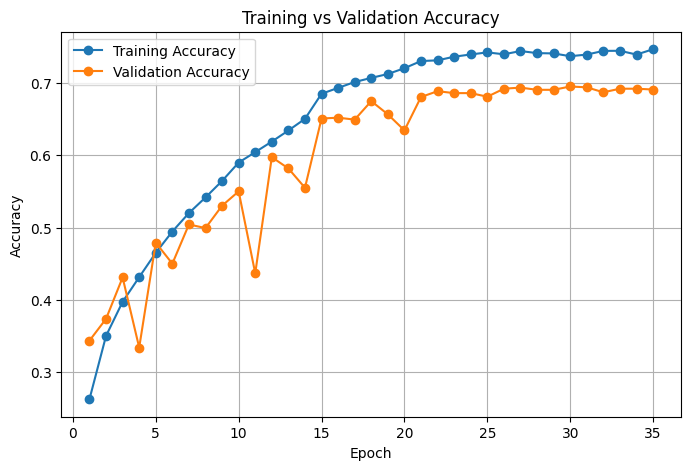

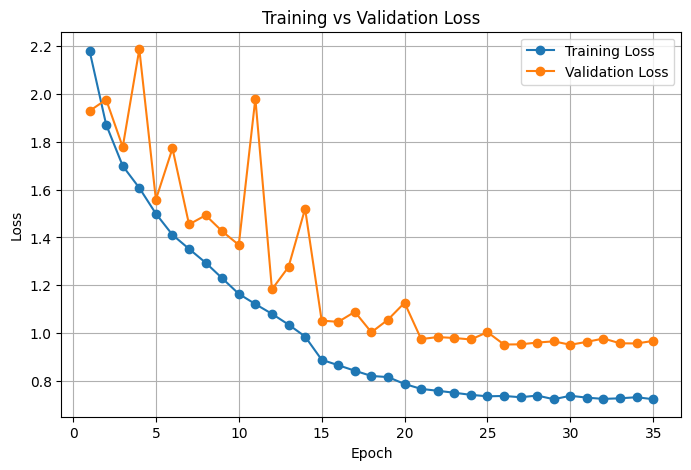

In [11]:
# ============================================================
# 9) Accuracy and Loss Graphs
# ============================================================

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(accuracy) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, accuracy, marker="o", label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, marker="o", label="Training Loss")
plt.plot(epochs_range, val_loss, marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


83/83 [==============================] - 4s 46ms/step
Classification Report:
              precision    recall  f1-score   support

       araña       0.90      0.78      0.83       483
     ardilla       0.68      0.73      0.71       187
     caballo       0.86      0.63      0.73       263
    elefante       0.41      0.95      0.57       146
     gallina       0.81      0.83      0.82       311
        gato       0.58      0.61      0.59       168
    mariposa       0.73      0.91      0.81       212
       oveja       0.63      0.77      0.70       182
       perro       0.87      0.48      0.62       487
        vaca       0.63      0.73      0.67       188

    accuracy                           0.72      2627
   macro avg       0.71      0.74      0.70      2627
weighted avg       0.76      0.72      0.72      2627



<Figure size 1000x1000 with 0 Axes>

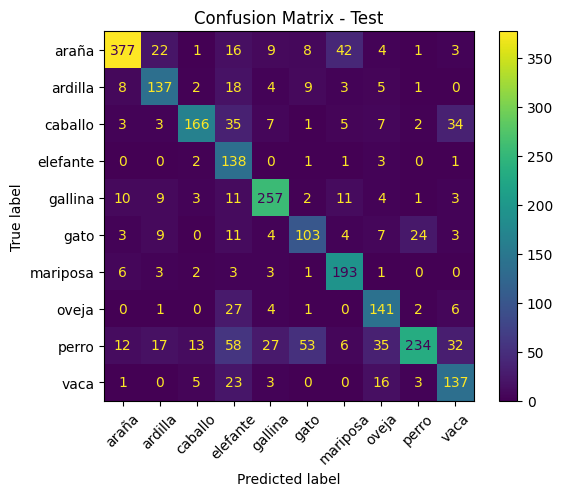

In [12]:
# ============================================================
# 10) Confusion Matrix and Classification Report
# ============================================================

test_generator.reset()

pred_probs = best_model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

labels = list(range(train_generator.num_classes))
target_names = [index_to_class[i] for i in labels]

print("Classification Report:")
print(classification_report(y_true, y_pred, labels=labels, target_names=target_names))

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix - Test")
plt.show()


In [13]:
# ============================================================
# 11) Individual Image Prediction
# ============================================================

from tensorflow.keras.preprocessing import image

def predict_image(img_path, model_path=checkpoint_path):
    loaded_model = load_model(model_path)

    img = image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Same rescaling as training

    pred = loaded_model.predict(img_array)
    pred_index = int(np.argmax(pred, axis=1)[0])
    confidence = float(np.max(pred))

    class_name = index_to_class[pred_index]

    print(f"Predicted class: {class_name} ({class_name})")
    print(f"Confidence: {confidence:.4f}")

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_name} - {confidence:.2%}")
    plt.show()

    return class_name, confidence

# Example usage:
# predict_image("Animals_Dataset_Splitted/test/gato/some_image.jpeg")


In [14]:
# Celda final para auto-pushear a GitHub
print("Entrenamiento finalizado. Subiendo al repositorio...")

!git add .
!git commit -m "Auto-push: Entrenamiento de modelo CM finalizado"
!git push

print("¡Push completado con éxito!")


Entrenamiento finalizado. Subiendo al repositorio...


[master 3190f969] Auto-push: Entrenamiento de modelo CM finalizado
 10 files changed, 346 insertions(+), 468 deletions(-)
¡Push completado con éxito!


remote: warning: See https://gh.io/lfs for more information.        
remote: warning: File mejor_modelo_VGG16.keras is 57.74 MB; this is larger than GitHub's recommended maximum file size of 50.00 MB        
remote: warning: GH001: Large files detected. You may want to try Git Large File Storage - https://git-lfs.github.com.        
To https://github.com/santinohamada/TP3-IA.git
   645e137d..3190f969  master -> master
